In [6]:
# --- All Imports ---
import mysql.connector
import pandas as pd
import requests
import time
import ipaddress
import logging
import os # For creating log directory if needed
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # New import for plotting
import seaborn as sns # New import for plotting

# --- Database connection details ---
# IMPORTANT: Replace with your actual database credentials if different
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '9715xjon',
    'database': 'working_db',
    'port': 3306
}

# --- Initialize DataFrames ---
df_activity = pd.DataFrame()
df_weather = pd.DataFrame()
df_activity_with_weather = pd.DataFrame()

# --- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---
print("--- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---")

try:
    # Establish the connection
    cnx = mysql.connector.connect(**DB_CONFIG)
    if cnx.is_connected():
        print("Successfully connected to the database.")
    else:
        print("Failed to connect to the database.")
        raise ConnectionError("Database connection failed.")

    # Fetching the combined user activity table
    print("\nFetching data from 'combined_user_activity' table...")
    query_activity = "SELECT * FROM combined_user_activity;"
    df_activity = pd.read_sql(query_activity, cnx)

    print(f"'combined_user_activity' table loaded. Rows: {len(df_activity)}")
    print("Head of df_activity (initial load):")
    print(df_activity.head())
    print("\nInitial Info of df_activity:")
    df_activity.info()

    # Initial Data Cleaning and Type Conversion for df_activity
    print("\n--- Performing Data Type Conversions for df_activity ---")

    # Convert 'activity_created_on' to datetime objects
    df_activity['activity_created_on'] = pd.to_datetime(df_activity['activity_created_on'])
    print("Converted 'activity_created_on' to datetime.")

    # Convert 'currenttime' and 'lasteditedon' (if they are datetime-like and not already)
    for col in ['currenttime', 'lasteditedon']:
        if col in df_activity.columns and df_activity[col].dtype == 'object':
            df_activity[col] = pd.to_datetime(df_activity[col], errors='coerce')
            if df_activity[col].isnull().any():
                print(f"Warning: Some values in '{col}' could not be converted to datetime and were set to NaT.")
            print(f"Converted '{col}' to datetime.")
    
    # Convert numeric columns like 'duration' and 'amount' if they are not already numeric
    for col in ['duration', 'amount']:
        if col in df_activity.columns and not pd.api.types.is_numeric_dtype(df_activity[col]):
            df_activity[col] = pd.to_numeric(df_activity[col], errors='coerce')
            if df_activity[col].isnull().any():
                print(f"Warning: Some values in '{col}' could not be converted to numeric and were set to NaN.")
            print(f"Converted '{col}' to numeric.")

    # Ensure 'country_code' is properly set for merging (based on previous discussions, assuming 'locale' if 'country_code' is missing)
    if 'country_code' not in df_activity.columns:
        print("Warning: 'country_code' column not found directly. Assuming 'locale' can serve as country code for now.")
        df_activity['country_code'] = df_activity['locale']
    print(f"Using column '{'country_code' if 'country_code' in df_activity.columns else 'locale'}' for country identification.")

    print("\nUpdated Info of df_activity after conversions:")
    df_activity.info()
    print("\nFirst 5 rows of df_activity after conversions:")
    print(df_activity.head())

except mysql.connector.Error as err:
    print(f"MySQL Error: {err}")
    if err.errno == mysql.connector.errorcode.ER_ACCESS_DENIED_ERROR:
        print("Something is wrong with your user name or password")
    elif err.errno == mysql.connector.errorcode.ER_BAD_DB_ERROR:
        print("Database does not exist")
    else:
        print(err)
except Exception as e:
    print(f"An unexpected error occurred during data loading or conversion: {e}")
finally:
    if 'cnx' in locals() and cnx.is_connected():
        cnx.close()
        print("\nDatabase connection closed.")

print("\n--- df_activity loading and initial processing complete. ---")

if df_activity.empty:
    print("\nCRITICAL ERROR: df_activity is empty. Please resolve database connection/query issues before proceeding.")
else:
    print(f"\nSuccessfully loaded {len(df_activity)} records into df_activity.")

--- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---
Successfully connected to the database.

Fetching data from 'combined_user_activity' table...


C:\Users\biggm\AppData\Local\Temp\ipykernel_6712\638191495.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_activity = pd.read_sql(query_activity, cnx)


'combined_user_activity' table loaded. Rows: 33839
Head of df_activity (initial load):
  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title                                             genres  \
0   

In [7]:
# --- CELL 2: Load Weather Data from CSV ---
print("\n--- CELL 2: Load Weather Data from CSV ---")

try:
    # --- Using the full path you provided in previous interactions ---
    # IMPORTANT: Update this path if your weather_data.CSV is in a different location
    csv_file_path = r'C:\Users\biggm\OneDrive\Desktop\ClimatePricingProject\data\weather_data.CSV'
    df_weather = pd.read_csv(csv_file_path)

    print(f"\nWeather data loaded from CSV: {csv_file_path}. Rows: {len(df_weather)}")
    print("Head of df_weather (initial load):")
    print(df_weather.head())
    print("\nInitial Info of df_weather:")
    df_weather.info()

    # Data Type Conversions for df_weather
    # Convert the date column in your weather CSV ('time' based on your screenshot) to datetime objects
    if 'time' in df_weather.columns:
        df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce').dt.date
        print("Converted 'time' column in df_weather to date objects.")
    elif 'date' in df_weather.columns:
        df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce').dt.date
        print("Converted 'date' column in df_weather to date objects.")
    elif 'weather_date' in df_weather.columns:
        df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
        print("Converted 'weather_date' column in df_weather to date objects.")
    else:
        print("Warning: No common date column ('time', 'date', or 'weather_date') found in your weather CSV for conversion. Please adjust the code if needed.")
        
    print("\nUpdated Info of df_weather after initial conversions:")
    df_weather.info()
    
except FileNotFoundError:
    print(f"ERROR: Weather data CSV not found at '{csv_file_path}'. Please check the file path and name.")
    print("Make sure the file exists and the path is correct, including case-sensitivity for the filename.")
except Exception as e:
    print(f"An error occurred while loading or processing the weather CSV: {e}")

if df_weather.empty:
    print("\nCRITICAL ERROR: df_weather is empty. Please ensure your CSV is correctly loaded and has data.")
else:
    print(f"\nSuccessfully loaded {len(df_weather)} records into df_weather from CSV.")


--- CELL 2: Load Weather Data from CSV ---

Weather data loaded from CSV: C:\Users\biggm\OneDrive\Desktop\ClimatePricingProject\data\weather_data.CSV. Rows: 9608
Head of df_weather (initial load):
         time  temperature_2m_max  temperature_2m_min  \
0  2019-01-01                24.8                13.9   
1  2019-01-02                25.4                14.3   
2  2019-01-03                24.6                15.0   
3  2019-01-04                20.8                15.3   
4  2019-01-05                22.7                13.9   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      25.5                      13.0                0.0   
1                      26.0                      13.7                0.0   
2                      25.0                      14.8                0.1   
3                      21.7                      15.6               13.5   
4                      22.7                      13.9                5.6   

  

In [8]:
# --- CELL 3: Prepare df_weather for Merge ---
print("\n--- CELL 3: Prepare df_weather for Merge ---")

if not df_weather.empty:
    # Rename the 'time' column to 'weather_date' for consistency and clearer merge
    if 'time' in df_weather.columns:
        df_weather.rename(columns={'time': 'weather_date'}, inplace=True)
        print("Renamed 'time' column in df_weather to 'weather_date'.")
    elif 'date' in df_weather.columns and 'weather_date' not in df_weather.columns:
        df_weather.rename(columns={'date': 'weather_date'}, inplace=True)
        print("Renamed 'date' column in df_weather to 'weather_date'.")
    
    # Ensure 'weather_date' is in date format (important for merging)
    if 'weather_date' in df_weather.columns:
         df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
         print("Ensured 'weather_date' column is in date format.")
    else:
        print("Warning: 'weather_date' column (or original 'time'/'date') not found after renaming. Check Cell 2 and this cell's renaming logic.")

    # Add a 'country_code' column to df_weather based on the 'city' column
    # IMPORTANT: Ensure these mappings are correct for your specific data.
    if 'city' in df_weather.columns:
        df_weather['country_code'] = df_weather['city'].map({
            'Nairobi': 'KE',
            'Mombasa': 'KE',
            'Kisumu': 'KE',
            'Lagos': 'NG',
            'Dubai': 'AE',
            'New York': 'US',
            # Add more city: country_code mappings as needed
        })
        print("Added 'country_code' to df_weather based on 'city' column.")
        if df_weather['country_code'].isnull().any():
            print("Warning: Some cities in df_weather could not be mapped to a country_code. Check 'city' column for unmapped values.")
            print("Cities with no country_code assigned:", df_weather[df_weather['country_code'].isnull()]['city'].unique())
    else:
        print("Warning: 'city' column not found in df_weather. Cannot infer 'country_code'. Please add 'country_code' manually or from another source if your CSV doesn't contain it.")

    # Aggregate df_weather by country_code and weather_date
    # This is crucial because df_activity will no longer have a 'city' column for merging,
    # and we need a single, representative weather entry per country per day.
    print("\nAggregating df_weather by country_code and weather_date...")
    
    # Define aggregation methods for numerical and categorical columns
    aggregation_methods = {
        col: 'mean' for col in df_weather.select_dtypes(include=['number']).columns if col not in ['weathercode']
    }
    # For weathercode, use mode (most frequent)
    if 'weathercode' in df_weather.columns:
        aggregation_methods['weathercode'] = lambda x: x.mode()[0] if not x.mode().empty else None

    # Ensure 'weather_date' and 'country_code' are not included in aggregation values
    if 'weather_date' in aggregation_methods:
        del aggregation_methods['weather_date']
    if 'country_code' in aggregation_methods:
        del aggregation_methods['country_code']
    if 'city' in aggregation_methods: # Remove city from aggregation values, it's a grouping key
        del aggregation_methods['city']

    df_weather_aggregated = df_weather.groupby(['country_code', 'weather_date']).agg(aggregation_methods).reset_index()
    
    print("Aggregation complete. Head of aggregated weather data:")
    print(df_weather_aggregated.head())
    print("\nInfo of df_weather_aggregated:")
    df_weather_aggregated.info()

    # Replace the original df_weather with the aggregated one for the merge
    df_weather = df_weather_aggregated

    print("\nUpdated Head of df_weather after preparation:")
    print(df_weather.head())
    print("\nUpdated Info of df_weather after preparation:")
    df_weather.info()
else:
    print("df_weather is empty, skipping preparation for merge.")


--- CELL 3: Prepare df_weather for Merge ---
Renamed 'time' column in df_weather to 'weather_date'.
Ensured 'weather_date' column is in date format.
Added 'country_code' to df_weather based on 'city' column.

Aggregating df_weather by country_code and weather_date...
Aggregation complete. Head of aggregated weather data:
  country_code weather_date  temperature_2m_max  temperature_2m_min  \
0           AE   2019-01-01                25.4                15.2   
1           AE   2019-01-02                25.9                15.5   
2           AE   2019-01-03                28.0                14.3   
3           AE   2019-01-04                26.0                17.0   
4           AE   2019-01-05                24.8                16.4   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      26.0                      15.2                0.0   
1                      25.9                      15.0                0.0   
2                    

In [9]:
# --- CELL 4: IP Address Geolocation and City Extraction for df_activity ---
# This cell has been removed as per your request.
# The 'city' column will no longer be added to df_activity via IP geolocation.

In [10]:
# --- CELL 5: Perform the Merge of df_activity and df_weather ---
print("\n--- CELL 5: Perform the Merge with Weather Data ---")

# Ensure 'activity_date' is available in df_activity (from Cell 1 or created here for safety)
if 'activity_date' not in df_activity.columns:
    df_activity['activity_date'] = df_activity['activity_created_on'].dt.date

# Determine the date column name in df_weather for merging
weather_date_col = None
if 'date' in df_weather.columns:
    weather_date_col = 'date'
elif 'weather_date' in df_weather.columns:
    weather_date_col = 'weather_date'
elif 'time' in df_weather.columns: # Fallback if not renamed yet
    weather_date_col = 'time'

if weather_date_col is None:
    print("ERROR: No suitable date column found in df_weather for merging. Please check Cell 2 and Cell 3.")
else:
    df_activity_with_weather = pd.merge(
        df_activity,
        df_weather,
        # Merging only on country_code and date, as city is no longer in df_activity
        left_on=['country_code', 'activity_date'],
        right_on=['country_code', weather_date_col],
        how='left' # Use left join to keep all activity records
    )

    # Drop the redundant weather date column after merge if it's different from activity_date
    if weather_date_col != 'activity_date' and weather_date_col in df_activity_with_weather.columns:
        df_activity_with_weather = df_activity_with_weather.drop(columns=[weather_date_col])

    print("\nShape of df_activity_with_weather after merging with weather:", df_activity_with_weather.shape)
    print("Head of df_activity_with_weather (showing new weather columns):")
    print(df_activity_with_weather.head())
    print("\nInfo of df_activity_with_weather:")
    df_activity_with_weather.info()

    print("\n--- Weather Data Integration Complete! ---")
    print("Your 'df_activity_with_weather' DataFrame now contains combined user activity and historical weather information.")


--- CELL 5: Perform the Merge with Weather Data ---

Shape of df_activity_with_weather after merging with weather: (33839, 29)
Head of df_activity_with_weather (showing new weather columns):
  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 20

In [11]:
# --- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---
print("\n--- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---")

# --- Handling NaN from UNION ALL (e.g., 'platform' for purchases, 'amount' for views) ---
print("\nHandling NaNs from UNION ALL operation (e.g., 'platform' for purchases, 'amount' for views)...")

# Categorical columns where NaN means 'Not Applicable'
union_categorical_cols = ['platform', 'ipaddress', 'source', 'currency', 'purchase_type']
for col in union_categorical_cols:
    if col in df_activity_with_weather.columns and df_activity_with_weather[col].dtype == 'object':
        # Use direct assignment instead of inplace=True to avoid FutureWarning
        df_activity_with_weather[col] = df_activity_with_weather[col].fillna('N/A')
        print(f"Filled NaN in '{col}' with 'N/A'.")

# Numerical columns where NaN means 'Not Applicable' (keep as NaN or fill with 0 based on context)
# For 'currenttime' (view duration) and 'amount' (purchase amount), NaN is meaningful.
# If a model absolutely requires no NaNs, you might fill with 0, but be cautious.
# For this general setup, we'll leave them as NaN, as many ML models can handle them.
# If you need to fill them, uncomment the lines below:
# if 'currenttime' in df_activity_with_weather.columns:
#     df_activity_with_weather['currenttime'] = df_activity_with_weather['currenttime'].fillna(0)
#     print("Filled NaN in 'currenttime' with 0.")
# if 'amount' in df_activity_with_weather.columns:
#     df_activity_with_weather['amount'] = df_activity_with_weather['amount'].fillna(0)
#     print("Filled NaN in 'amount' with 0.")

# 'lasteditedon' is datetime, NaT is appropriate for missing.

# --- Handling NaNs from Weather Data Merge ---
print("\nHandling NaNs from weather data merge (truly missing weather info)...")

# Get list of weather columns (adjust if your weather CSV has different names)
weather_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max',
    'apparent_temperature_min', 'precipitation_sum', 'rain_sum',
    'weathercode', 'windspeed_10m_max'
]

# Impute numerical weather columns
for col in weather_cols:
    if col in df_activity_with_weather.columns:
        if df_activity_with_weather[col].isnull().any():
            # For precipitation, 0 is a reasonable fill if data is missing
            if 'precipitation' in col or 'rain' in col:
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(0)
                print(f"Imputed missing '{col}' with 0.")
            # For temperature and windspeed, median is a robust choice
            elif 'temperature' in col or 'windspeed' in col:
                median_val = df_activity_with_weather[col].median()
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(median_val)
                print(f"Imputed missing '{col}' with median: {median_val:.2f}.")
            # For weathercode, mode or a specific placeholder like -1
            elif 'weathercode' in col:
                # Option 1: Fill with mode
                mode_val = df_activity_with_weather[col].mode()[0]
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(mode_val)
                print(f"Imputed missing '{col}' with mode: {mode_val}.")
                # Option 2: Fill with a distinct numerical placeholder (e.g., -1)
                # df_activity_with_weather[col] = df_activity_with_weather[col].fillna(-1)
                # print(f"Imputed missing '{col}' with -1.")

# --- Final Verification of NaNs ---
print("\nFinal NaN counts in df_activity_with_weather after all handling:")
print(df_activity_with_weather.isnull().sum())

print("\nHead of df_activity_with_weather after all NaN handling:")
print(df_activity_with_weather.head())

print("\n--- Data Preparation Complete! ---")
print("Your 'df_activity_with_weather' DataFrame is now ready for Exploratory Data Analysis and Feature Engineering.")


--- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---

Handling NaNs from UNION ALL operation (e.g., 'platform' for purchases, 'amount' for views)...
Filled NaN in 'platform' with 'N/A'.
Filled NaN in 'ipaddress' with 'N/A'.
Filled NaN in 'source' with 'N/A'.
Filled NaN in 'currency' with 'N/A'.
Filled NaN in 'purchase_type' with 'N/A'.

Handling NaNs from weather data merge (truly missing weather info)...
Imputed missing 'temperature_2m_max' with median: 25.10.
Imputed missing 'temperature_2m_min' with median: 15.20.
Imputed missing 'apparent_temperature_max' with median: 26.00.
Imputed missing 'apparent_temperature_min' with median: 15.40.
Imputed missing 'precipitation_sum' with 0.
Imputed missing 'rain_sum' with 0.
Imputed missing 'weathercode' with mode: 51.0.
Imputed missing 'windspeed_10m_max' with median: 13.70.

Final NaN counts in df_activity_with_weather after all handling:
record_type                     0
activity_id                     0
user_id             

In [12]:
df_activity_with_weather['amount']

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
33834    49.0
33835    49.0
33836     0.0
33837     0.0
33838     0.0
Name: amount, Length: 33839, dtype: float64

In [13]:
# --- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---
print("\n--- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Descriptive Statistics for Numerical Columns ---")
    print(df_activity_with_weather.describe().to_string()) # Use .to_string() to ensure full display


--- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---

--- Descriptive Statistics for Numerical Columns ---
        activity_id       user_id    content_id            activity_created_on   currenttime                   lasteditedon      duration          year        amount  temperature_2m_max  temperature_2m_min  apparent_temperature_max  apparent_temperature_min  precipitation_sum      rain_sum  windspeed_10m_max   weathercode
count  33839.000000  33839.000000  33839.000000                          33839   4690.000000                           4690  33839.000000  33839.000000  29149.000000        33839.000000        33839.000000              33839.000000              33839.000000       33839.000000  33839.000000       33839.000000  33839.000000
mean   13145.250776  12570.020686    120.433760  2023-12-30 14:42:03.832353024   2635.559915  2023-03-15 04:31:26.946268672     68.534708   2020.818819    170.722593           25.247425           14.969189                 25

In [14]:
# --- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---
print("\n--- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Record Type Distribution ---")
    print(df_activity_with_weather['record_type'].value_counts().to_string())


--- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---

--- Record Type Distribution ---
record_type
purchase    29149
view         4690


In [15]:
# --- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---
print("\n--- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Country Code Distribution ---")
    print(df_activity_with_weather['country_code'].value_counts().to_string())


--- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---

--- Country Code Distribution ---
country_code
KE    31238
NG      537
US      516
NZ      202
UG      175
TZ      145
RW      139
GB      121
AE       79
CA       72
IN       68
QA       51
DE       50
AU       46
FR       42
ZA       40
NL       28
SA       28
CH       23
GH       15
BE       15
TH       10
SE       10
ET        9
IT        9
SI        8
LB        8
RO        7
HR        6
KY        6
KW        6
TR        6
MU        6
NO        6
SC        6
JP        5
IE        5
SS        5
SO        5
BH        4
UA        4
BW        4
MW        4
SG        4
ZW        4
CD        3
GR        3
PL        3
CG        2
HU        2
HK        2
EG        2
AT        2
IQ        2
DJ        2
ZM        2
MX        2
GA        2
BI        2
RS        2
ES        2
JE        2
DZ        2
FI        2
ID        2
IL        2
BR        1
MZ        1
PH        1
SN        1
NA        1
MR        1
ML        1

In [16]:
# --- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---
print("\n--- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Platform Distribution (after NaN handling) ---")
    print(df_activity_with_weather['platform'].value_counts().to_string())


--- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---

--- Platform Distribution (after NaN handling) ---
platform
N/A                 29149
Android              2821
Windows 10           1375
Mac OS X              275
Linux                  96
Windows 7              65
Windows 8.1            29
iOS                    21
Unknown Platform        5
Windows 8               3


In [17]:
# --- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---
print("\n--- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Purchase Type Distribution (after NaN handling) ---")
    print(df_activity_with_weather['purchase_type'].value_counts().to_string())


--- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---

--- Purchase Type Distribution (after NaN handling) ---
purchase_type
RENTAL                       18697
PVOD                          6203
N/A                           4690
EST                           2406
SCREENING                      576
ZOOM SCREENING                 549
REGULAR OFFLINE SCREENING      239
OFFLINE SCREENING              159
BULK OFFLINE SCREENING         101
DUO OFFLINE SCREENING           79
TRIO OFFLINE SCREENING          34
MONO OFFLINE SCREENING          29
COUPLE OFFLINE SCREENING        27
OFFLINE SCREENIN                23
DOOR OFFLINE SCREENING           7
STUDENT OFFLINE SCREENING        5
SCREENING (DUO)                  5
SQUAD OFFLINE SCREENING          4
GETUP KENYA 2024                 3
GROUP OFFLINE SCREENING          2
UPSELL TO EST                    1



--- CELL 12: Initial Visualization - Histogram for Max Temperature ---


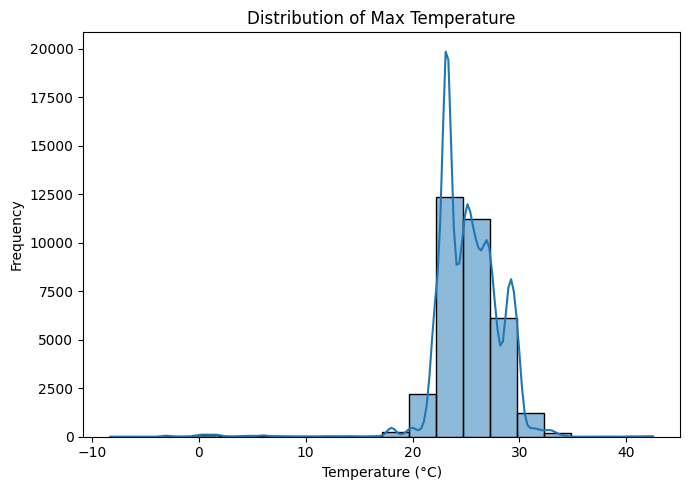

In [18]:
# --- CELL 12: Initial Visualization - Histogram for Max Temperature ---
print("\n--- CELL 12: Initial Visualization - Histogram for Max Temperature ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) # Adjusted size for single plot
    sns.histplot(df_activity_with_weather['temperature_2m_max'], kde=True, bins=20)
    plt.title('Distribution of Max Temperature')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


--- CELL 13: Initial Visualization - Histogram for Precipitation Sum ---


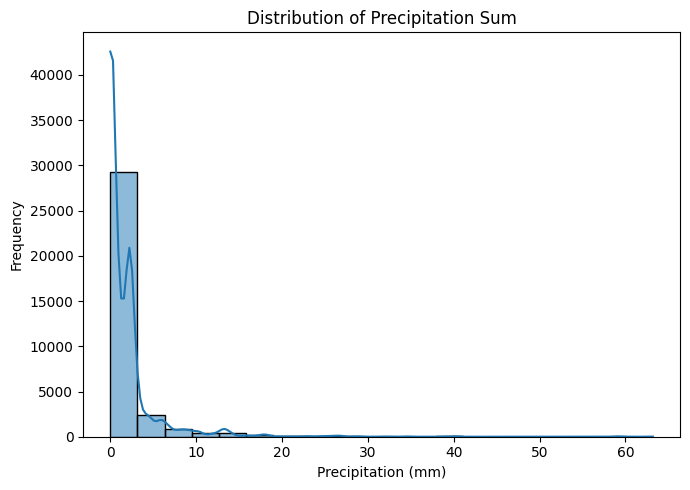

In [19]:
# --- CELL 13: Initial Visualization - Histogram for Precipitation Sum ---
print("\n--- CELL 13: Initial Visualization - Histogram for Precipitation Sum ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) # Adjusted size for single plot
    sns.histplot(df_activity_with_weather['precipitation_sum'], kde=True, bins=20)
    plt.title('Distribution of Precipitation Sum')
    plt.xlabel('Precipitation (mm)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


--- CELL 14: Initial Visualization - Count Plot for Record Type ---


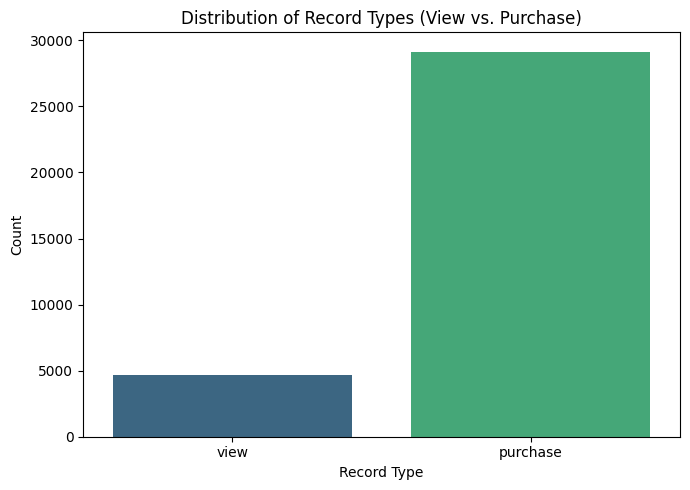

In [20]:
# --- CELL 14: Initial Visualization - Count Plot for Record Type ---
print("\n--- CELL 14: Initial Visualization - Count Plot for Record Type ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) # Adjusted size for single plot
    sns.countplot(x='record_type', data=df_activity_with_weather, palette='viridis', hue='record_type', legend=False)
    plt.title('Distribution of Record Types (View vs. Purchase)')
    plt.xlabel('Record Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


--- CELL 15: Initial Visualization - Histogram for Wind Speed ---


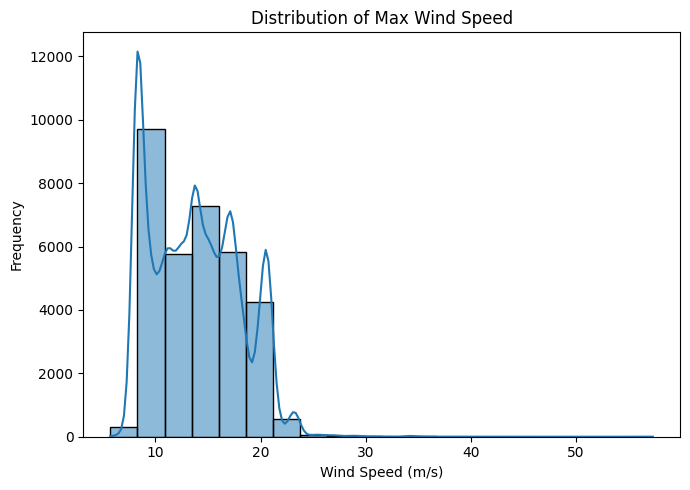

In [21]:
# --- CELL 15: Initial Visualization - Histogram for Wind Speed ---
print("\n--- CELL 15: Initial Visualization - Histogram for Wind Speed ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) 
    sns.histplot(df_activity_with_weather['windspeed_10m_max'], kde=True, bins=20)
    plt.title('Distribution of Max Wind Speed')
    plt.xlabel('Wind Speed (m/s)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


--- CELL 16: Initial Visualization - Count Plot for Weather Condition Category ---


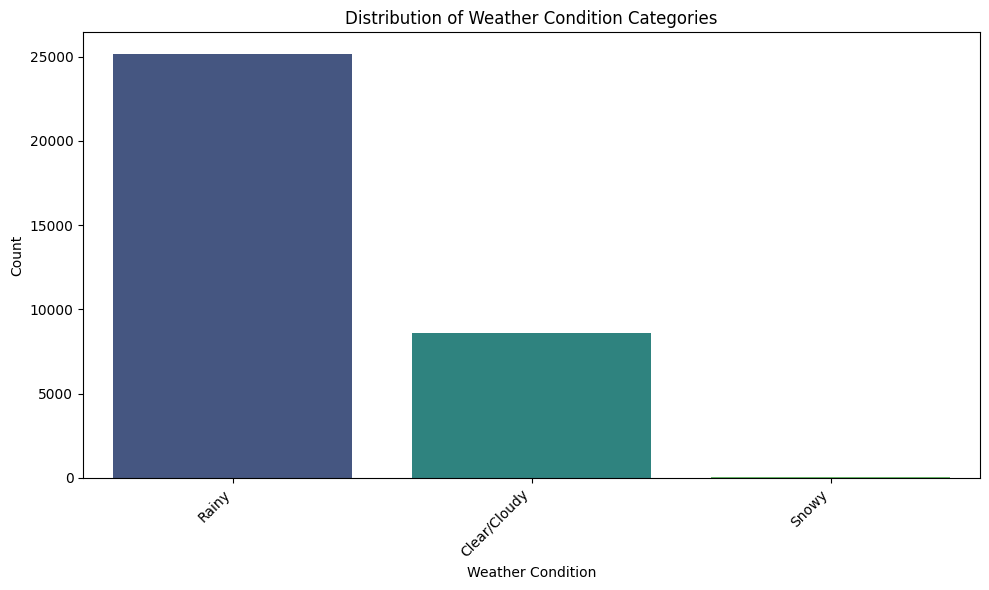

In [22]:
# --- CELL 16: Initial Visualization - Count Plot for Weather Condition Category ---
print("\n--- CELL 16: Initial Visualization - Count Plot for Weather Condition Category ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Define map_weathercode_to_condition function locally for this cell's execution
    def map_weathercode_to_condition(code):
        if code in [0, 1, 2, 3]: # Clear sky, partly cloudy
            return 'Clear/Cloudy'
        elif code in [45, 48]: # Fog, depositing rime fog
            return 'Foggy'
        elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]: # Drizzle, Rain, Rain showers
            return 'Rainy'
        elif code in [71, 73, 75, 77, 85, 86]: # Snow, snow grains, snow showers
            return 'Snowy'
        # Removed Freezing Rain/Drizzle as per user request
        elif code in [95, 96, 99]: # Thunderstorm, thunderstorm with hail
            return 'Thunderstorm'
        else:
            return 'Other' # Catch any unmapped codes
    
    # Create 'weather_condition_category' column if not already present
    if 'weather_condition_category' not in df_activity_with_weather.columns:
        df_activity_with_weather['weather_condition_category'] = df_activity_with_weather['weathercode'].apply(map_weathercode_to_condition)

    plt.figure(figsize=(10, 6)) 
    sns.countplot(x='weather_condition_category', data=df_activity_with_weather, palette='viridis', hue='weather_condition_category', legend=False)
    plt.title('Distribution of Weather Condition Categories')
    plt.xlabel('Weather Condition')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


--- CELL 17: Initial Visualization - Count Plot for Top N Country Codes ---


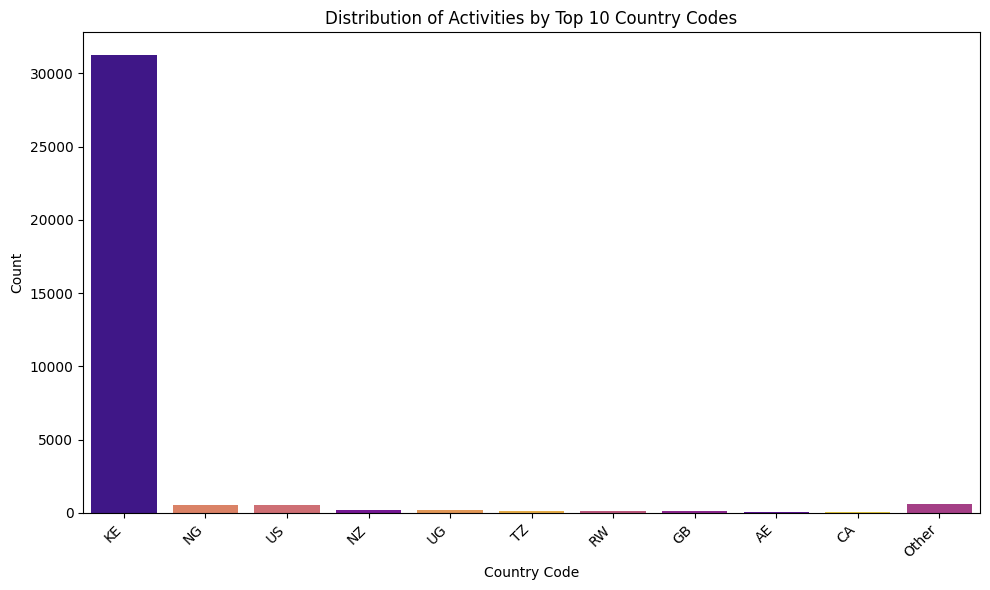

In [23]:
# --- CELL 17: Initial Visualization - Count Plot for Top N Country Codes ---
print("\n--- CELL 17: Initial Visualization - Count Plot for Top N Country Codes ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Calculate value counts for country codes
    country_counts = df_activity_with_weather['country_code'].value_counts()
    
    # Define N for top countries (e.g., top 10)
    N = 10 
    top_countries = country_counts.head(N).index
    
    # Create a new DataFrame for plotting, including 'Other' category
    df_plot_countries = df_activity_with_weather.copy()
    df_plot_countries['country_code_grouped'] = df_plot_countries['country_code'].apply(lambda x: x if x in top_countries else 'Other')

    plt.figure(figsize=(10, 6)) # Adjusted size for better readability
    # Use order to ensure 'Other' is at the end if desired, or let seaborn sort by count
    sns.countplot(x='country_code_grouped', data=df_plot_countries, palette='plasma', 
                  order=top_countries.tolist() + ['Other'] if 'Other' in df_plot_countries['country_code_grouped'].unique() else top_countries.tolist(),
                  hue='country_code_grouped', legend=False) # Added hue and legend=False
    plt.title(f'Distribution of Activities by Top {N} Country Codes')
    plt.xlabel('Country Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout()
    plt.show()

In [24]:
# --- CELL 19: Exploratory Data Analysis (EDA) - Deeper Dive into Relationships Overview ---
print("\n--- CELL 19: Exploratory Data Analysis (EDA) - Deeper Dive into Relationships Overview ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform deeper EDA. Please ensure previous cells ran successfully.")
else:
    print("The following cells (CELL 20 onwards) contain deeper visualizations exploring relationships between weather, activity, and content.")
    # Define map_weathercode_to_condition function globally for deeper EDA plots
    def map_weathercode_to_condition(code):
        if code in [0, 1, 2, 3]: # Clear sky, partly cloudy
            return 'Clear/Cloudy'
        elif code in [45, 48]: # Fog, depositing rime fog
            return 'Foggy'
        elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]: # Drizzle, Rain, Rain showers
            return 'Rainy'
        elif code in [71, 73, 75, 77, 85, 86]: # Snow, snow grains, snow showers
            return 'Snowy'
        elif code in [95, 96, 99]: # Thunderstorm, thunderstorm with hail
            return 'Thunderstorm'
        else:
            return 'Other' # Catch any unmapped codes
    
    # Create 'weather_condition_category' column if not already present, for use in subsequent cells
    if 'weather_condition_category' not in df_activity_with_weather.columns:
        df_activity_with_weather['weather_condition_category'] = df_activity_with_weather['weathercode'].apply(map_weathercode_to_condition)


--- CELL 19: Exploratory Data Analysis (EDA) - Deeper Dive into Relationships Overview ---
The following cells (CELL 20 onwards) contain deeper visualizations exploring relationships between weather, activity, and content.



--- CELL 20: Deeper EDA - Record Type Distribution by Weather Condition ---


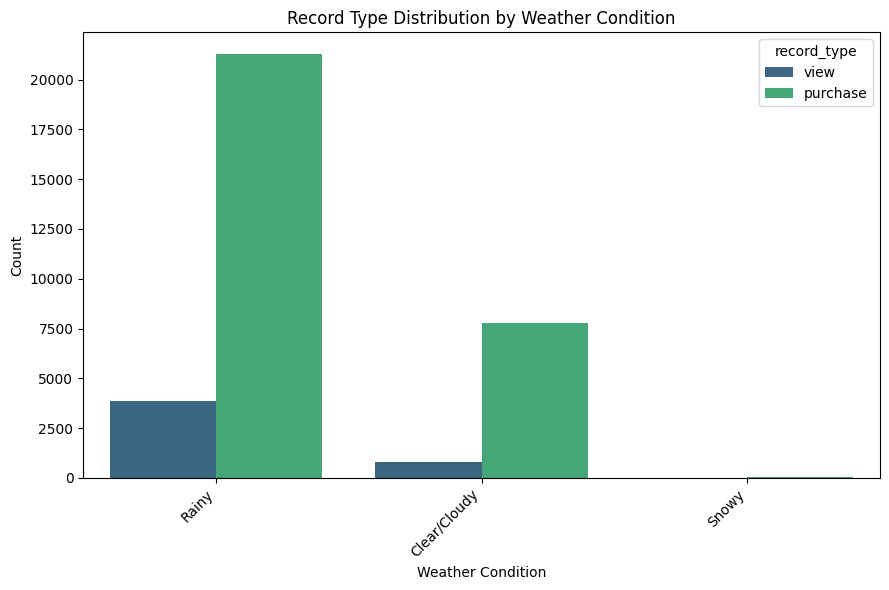

In [25]:
# --- CELL 20: Deeper EDA - Record Type Distribution by Weather Condition ---
print("\n--- CELL 20: Deeper EDA - Record Type Distribution by Weather Condition ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Ensure weather_condition_category is available (created in CELL 19)
    # If df_activity_with_weather was reloaded without CELL 19, this would need to be re-run
    # For robustness, include the definition here too if it's not guaranteed to be run before
    # For now, assuming CELL 19 (Overview) is run first.
    
    plt.figure(figsize=(9, 6)) # Adjusted size for single plot
    sns.countplot(x='weather_condition_category', hue='record_type', data=df_activity_with_weather, palette='viridis')
    plt.title('Record Type Distribution by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


--- CELL 21: Deeper EDA - Record Type Distribution by Temperature Range ---
Created 'temp_range' column.


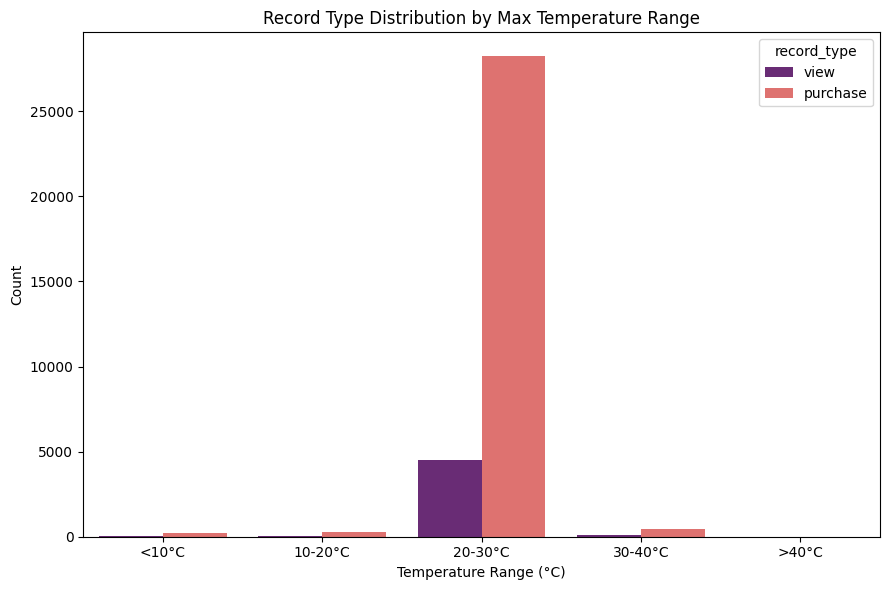

In [26]:
# --- CELL 21: Deeper EDA - Record Type Distribution by Temperature Range ---
print("\n--- CELL 21: Deeper EDA - Record Type Distribution by Temperature Range ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Create temperature bins if not already present
    if 'temp_range' not in df_activity_with_weather.columns:
        df_activity_with_weather['temp_range'] = pd.cut(df_activity_with_weather['temperature_2m_max'],
                                                        bins=[-10, 10, 20, 30, 40, 50],
                                                        labels=['<10°C', '10-20°C', '20-30°C', '30-40°C', '>40°C'],
                                                        right=False)
        print("Created 'temp_range' column.")

    plt.figure(figsize=(9, 6)) # Adjusted size for single plot
    sns.countplot(x='temp_range', hue='record_type', data=df_activity_with_weather, palette='magma', order=['<10°C', '10-20°C', '20-30°C', '30-40°C', '>40°C'])
    plt.title('Record Type Distribution by Max Temperature Range')
    plt.xlabel('Temperature Range (°C)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


--- CELL 22: Deeper EDA - Average View Duration by Weather Condition ---


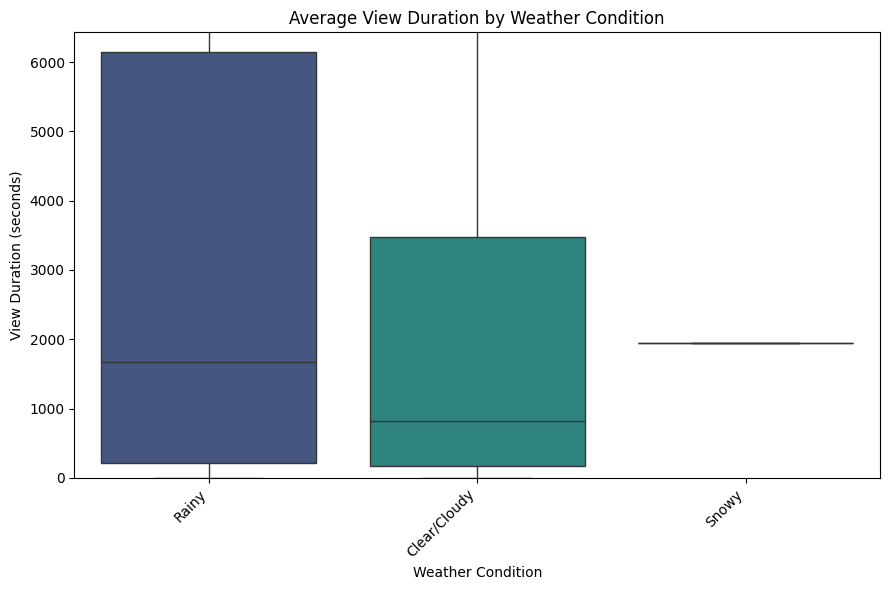

In [27]:
# --- CELL 22: Deeper EDA - Average View Duration by Weather Condition ---
print("\n--- CELL 22: Deeper EDA - Average View Duration by Weather Condition ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    df_views = df_activity_with_weather[df_activity_with_weather['record_type'] == 'view'].copy()
    
    plt.figure(figsize=(9, 6)) # Adjusted size for single plot
    sns.boxplot(x='weather_condition_category', y='currenttime', data=df_views, hue='weather_condition_category', palette='viridis', legend=False)
    plt.title('Average View Duration by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('View Duration (seconds)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_views['currenttime'].quantile(0.95)) # Limit y-axis to focus on main distribution
    plt.tight_layout()
    plt.show()



--- CELL 23: Deeper EDA - Average Purchase Amount by Weather Condition ---


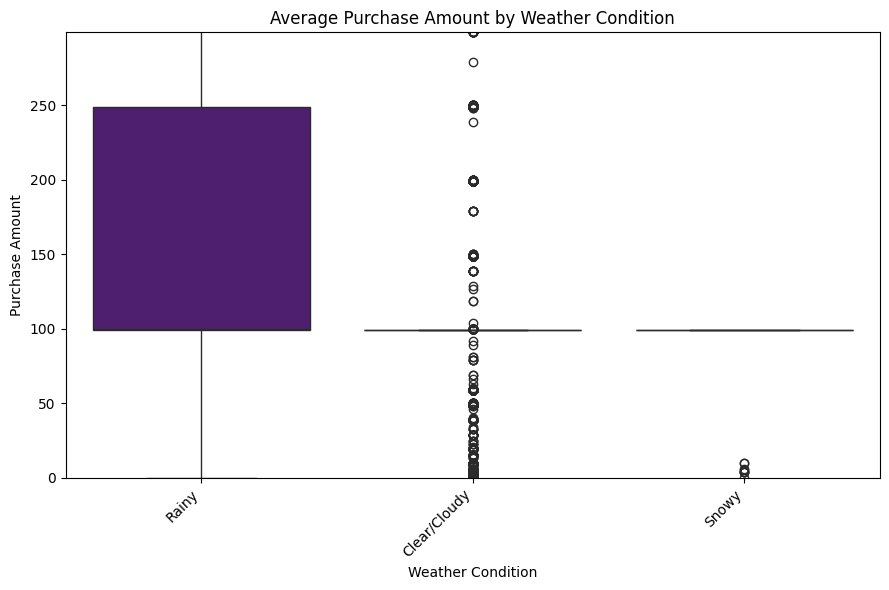

In [28]:
# --- CELL 23: Deeper EDA - Average Purchase Amount by Weather Condition ---
print("\n--- CELL 23: Deeper EDA - Average Purchase Amount by Weather Condition ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    df_purchases = df_activity_with_weather[df_activity_with_weather['record_type'] == 'purchase'].copy()
    
    plt.figure(figsize=(9, 6)) # Adjusted size for single plot
    sns.boxplot(x='weather_condition_category', y='amount', data=df_purchases, hue='weather_condition_category', palette='magma', legend=False)
    plt.title('Average Purchase Amount by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Purchase Amount')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_purchases['amount'].quantile(0.95)) # Limit y-axis to focus on main distribution
    plt.tight_layout()
    plt.show()


--- CELL 24: Deeper EDA - Correlation Heatmap ---


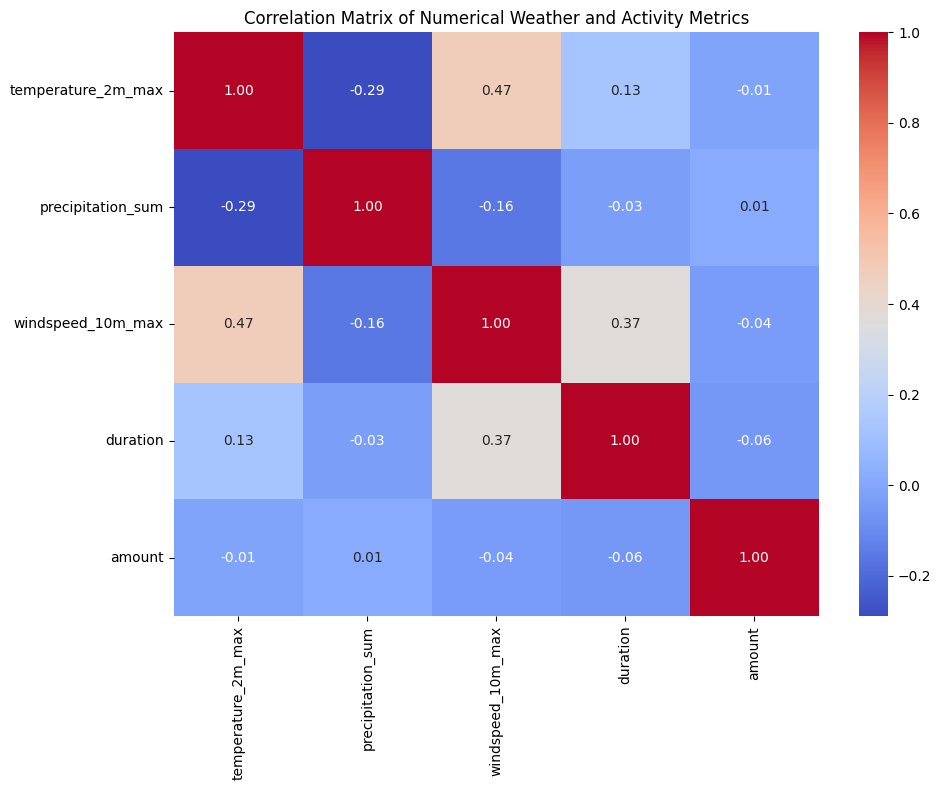

In [29]:
# --- CELL 24: Deeper EDA - Correlation Heatmap ---
print("\n--- CELL 24: Deeper EDA - Correlation Heatmap ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    numerical_cols = ['temperature_2m_max', 'precipitation_sum', 'windspeed_10m_max', 'duration', 'amount']
    corr_df = df_activity_with_weather[numerical_cols].dropna()
    
    plt.figure(figsize=(10, 8)) # Adjusted size for single plot
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Weather and Activity Metrics')
    plt.tight_layout()
    plt.show()


--- CELL 25: Deeper EDA - Genre Analysis Setup & Top Genres by Weather Condition ---

--- Genre Analysis by Weather ---


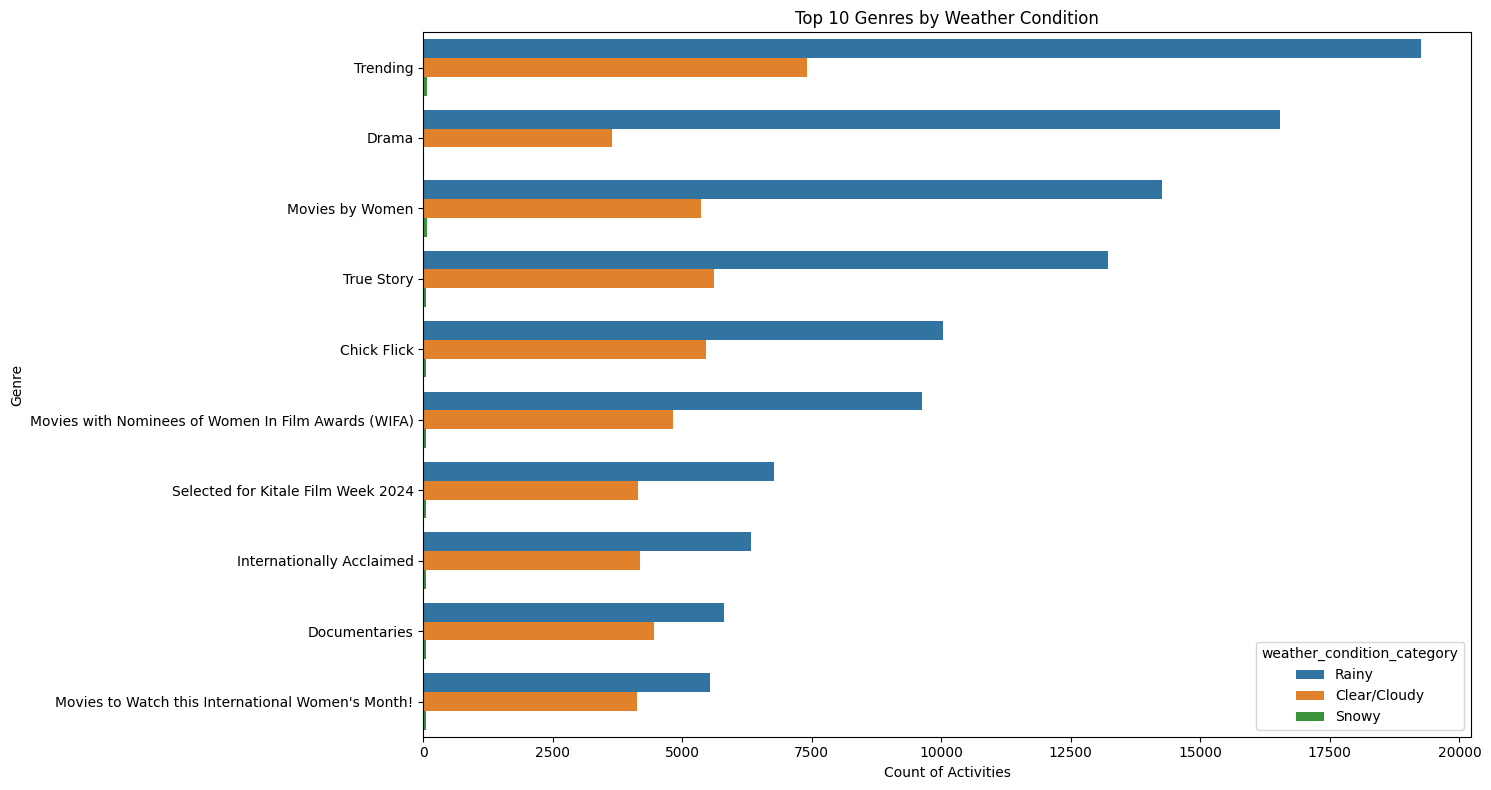

In [30]:
# --- CELL 25: Deeper EDA - Genre Analysis Setup & Top Genres by Weather Condition ---
print("\n--- CELL 25: Deeper EDA - Genre Analysis Setup & Top Genres by Weather Condition ---")
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform genre analysis. Please ensure previous cells ran successfully.")
else:
    print("\n--- Genre Analysis by Weather ---")

    # Explode genres into separate rows for analysis
    # First, clean up genres column if it still has non-list strings (e.g., 'N/A')
    # Convert string representation of list to actual list
    df_activity_with_weather['genres_list'] = df_activity_with_weather['genres'].apply(
        lambda x: eval(x) if isinstance(x, str) and x.startswith('[') and x.endswith(']') else []
    )
    # Filter out empty lists or 'N/A' from genres_list
    df_genres_exploded = df_activity_with_weather.explode('genres_list').reset_index(drop=True)
    df_genres_exploded = df_genres_exploded[df_genres_exploded['genres_list'].apply(lambda x: x not in ['N/A', '', 'TEST', 'TESTED'])]
    
    if not df_genres_exploded.empty:
        # Top Genres by Weather Condition (Count of activities)
        plt.figure(figsize=(15, 8))
        sns.countplot(y='genres_list', hue='weather_condition_category', data=df_genres_exploded, order=df_genres_exploded['genres_list'].value_counts().index[:10], palette='tab10')
        plt.title('Top 10 Genres by Weather Condition')
        plt.xlabel('Count of Activities')
        plt.ylabel('Genre')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid genre data found after exploding for genre analysis.")


--- CELL 26: Deeper EDA - Average Duration/Amount for Top Genres by Weather ---


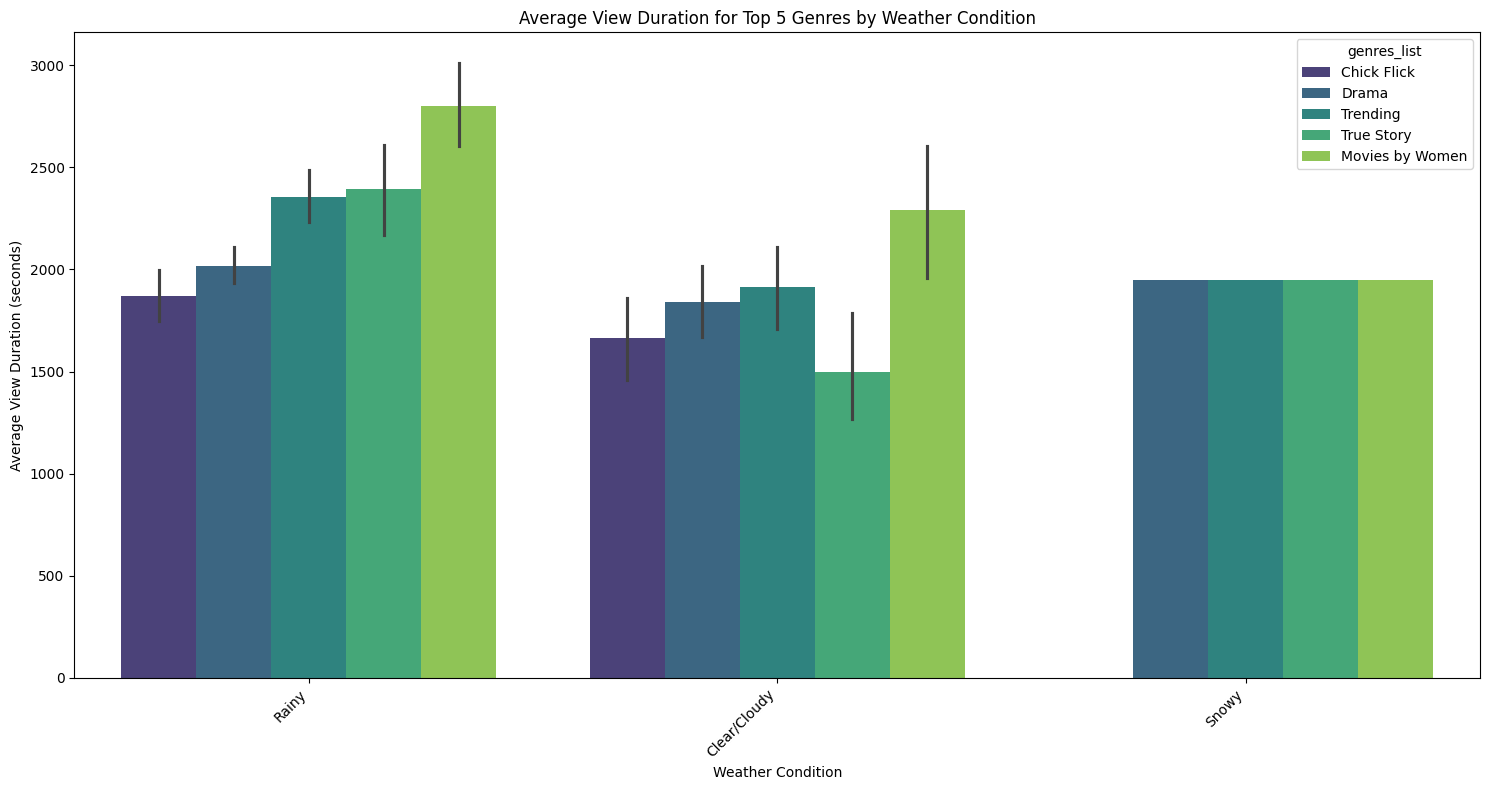


Deeper EDA complete. Analyze the outputs and plots for more insights.


In [31]:
# --- CELL 26: Deeper EDA - Average Duration/Amount for Top Genres by Weather ---
print("\n--- CELL 26: Deeper EDA - Average Duration/Amount for Top Genres by Weather ---")
if df_activity_with_weather.empty or 'df_genres_exploded' not in locals() or df_genres_exploded.empty:
    print("df_activity_with_weather or df_genres_exploded is empty. Cannot perform genre analysis. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(15, 8))
    sns.barplot(x='weather_condition_category', y='currenttime', hue='genres_list',
                data=df_genres_exploded[df_genres_exploded['genres_list'].isin(df_genres_exploded['genres_list'].value_counts().index[:5])], # Top 5 genres
                estimator=lambda x: pd.Series(x).dropna().mean(), palette='viridis')
    plt.title('Average View Duration for Top 5 Genres by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Average View Duration (seconds)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\nDeeper EDA complete. Analyze the outputs and plots for more insights.")